###Data Exploration: db degraded

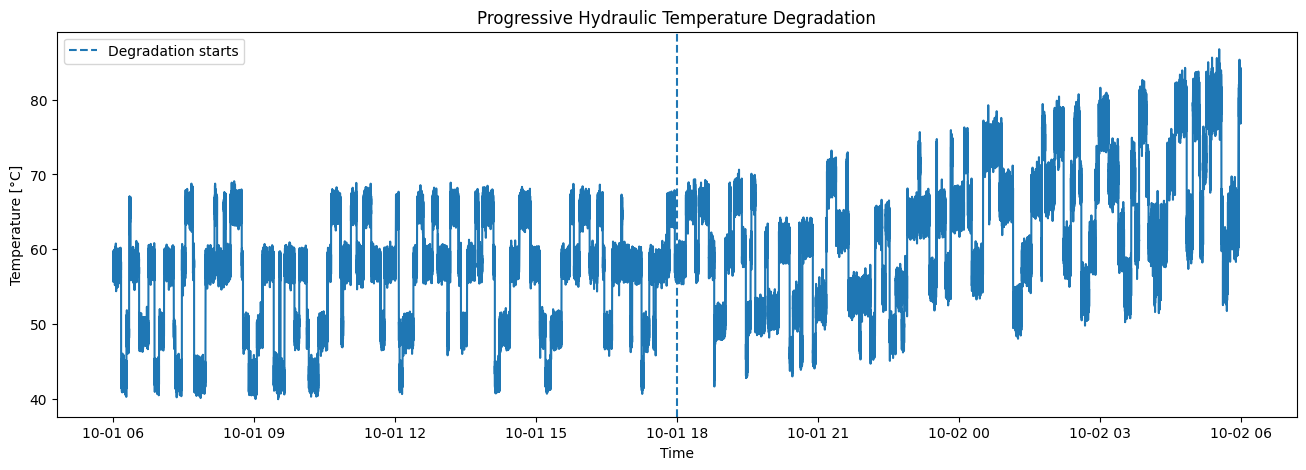

In [6]:
import sqlite3
import pandas as pd

DB_PATH = "/content/machine_telemetry_degraded.db"

with sqlite3.connect(DB_PATH) as conn:
    dataframe_machine_degraded = pd.read_sql_query(
        "SELECT * FROM machine_telemetry",
        conn,
        parse_dates=["timestamp"]
    )

dataframe_machine_degraded.head()
dataframe_machine_degraded["machine_condition"].value_counts()
dataframe_machine_degraded.groupby("machine_condition")[
    [
        "engine_temperature",
        "hydraulic_pressure",
        "hydraulic_temperature",
        "vibration",
        "fuel_rate",
    ]
].mean()

import matplotlib.pyplot as plt

plt.figure(figsize=(16, 5))

plt.plot(
    dataframe_machine_degraded["timestamp"],
    dataframe_machine_degraded["vibration"],
)

plt.axvline(
    dataframe_machine_degraded["timestamp"].min()
    + pd.Timedelta(hours=12),
    linestyle="--",
    label="Degradation starts",
)

plt.xlabel("Time")
plt.ylabel("hydraulic_temperature")
plt.title("Progressive Hydraulic Temperature Degradation")
plt.legend()

plt.show()

plt.figure(figsize=(16, 5))

plt.plot(
    dataframe_machine_degraded["timestamp"],
    dataframe_machine_degraded["hydraulic_temperature"],
)

plt.axvline(
    dataframe_machine_degraded["timestamp"].min()
    + pd.Timedelta(hours=12),
    linestyle="--",
    label="Degradation starts",
)

plt.xlabel("Time")
plt.ylabel("Temperature [°C]")
plt.title("Progressive Hydraulic Temperature Degradation")
plt.legend()

plt.show()

plt.figure(figsize=(16, 5))

plt.plot(
    dataframe_machine_degraded["timestamp"],
    dataframe_machine_degraded["hydraulic_pressure"],
)

plt.axvline(
    dataframe_machine_degraded["timestamp"].min()
    + pd.Timedelta(hours=12),
    linestyle="--",
    label="Degradation starts",
)

plt.xlabel("Time")
plt.ylabel("Pressure [bar]")
plt.title("Progressive Hydraulic Pressure Degradation")

plt.legend()
plt.show()

plt.figure(figsize=(16, 5))

plt.plot(
    dataframe_machine_degraded["timestamp"],
    dataframe_machine_degraded["fuel_rate"],
)

plt.axvline(
    dataframe_machine_degraded["timestamp"].min()
    + pd.Timedelta(hours=12),
    linestyle="--",
    label="Degradation starts",
)

plt.xlabel("Time")
plt.ylabel("Fuel rate [L/h]")
plt.title("Progressive Fuel Consumption Degradation")

plt.legend()
plt.show()